In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')


### Load Model and Scaled Dataset


In [2]:
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data" / "NSL-KDD"
MODELS_DIR = ROOT_DIR / "models"
OUTPUT_DIR = ROOT_DIR / "testing_outputs"

MODEL_FILE = MODELS_DIR / "nslkdd_full_rf_model.joblib"
SCALER_FILE = MODELS_DIR / "nslkdd_full_scaler.joblib"
TEST_FILE = DATA_DIR / "KDDTest+.txt"

model = joblib.load(MODEL_FILE)
scaler = joblib.load(SCALER_FILE)
print("Model and Scaler loaded.")


Model and Scaler loaded.


In [4]:
COLUMNS = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

test_df = pd.read_csv(TEST_FILE, names=COLUMNS)
y_test = (test_df["label"] != "normal").astype(int)
X_test = test_df.drop(columns=["label", "difficulty"]).copy()

# Apply identical label encoding to match training phase
train_df = pd.read_csv(DATA_DIR / "KDDTrain+.txt", names=COLUMNS)
X_train = train_df.drop(columns=["label", "difficulty"]).copy()

categorical_cols = ["protocol_type", "service", "flag"]
for col in categorical_cols:
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le = LabelEncoder()
    le.fit(combined)
    X_test[col] = le.transform(X_test[col].astype(str))
    
# Scale features
X_test_scaled = scaler.transform(X_test)
print("Test set preprocessed and scaled.")


Test set preprocessed and scaled.


### Run Predictions and Generate Metrics


In [5]:
print("Predicting on test set...")
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n--- Selected Model (Random Forest) Metrics ---")
print(f"Accuracy : {acc:.5f}")
print(f"Precision: {prec:.5f}")
print(f"Recall   : {rec:.5f}")
print(f"F1 Score : {f1:.5f}")
print(f"ROC-AUC  : {roc_auc:.5f}")


Predicting on test set...

--- Selected Model (Random Forest) Metrics ---
Accuracy : 0.77120
Precision: 0.96691
Recall   : 0.61926
F1 Score : 0.75499
ROC-AUC  : 0.96493


### Generate and Save Confusion Matrix Heatmap


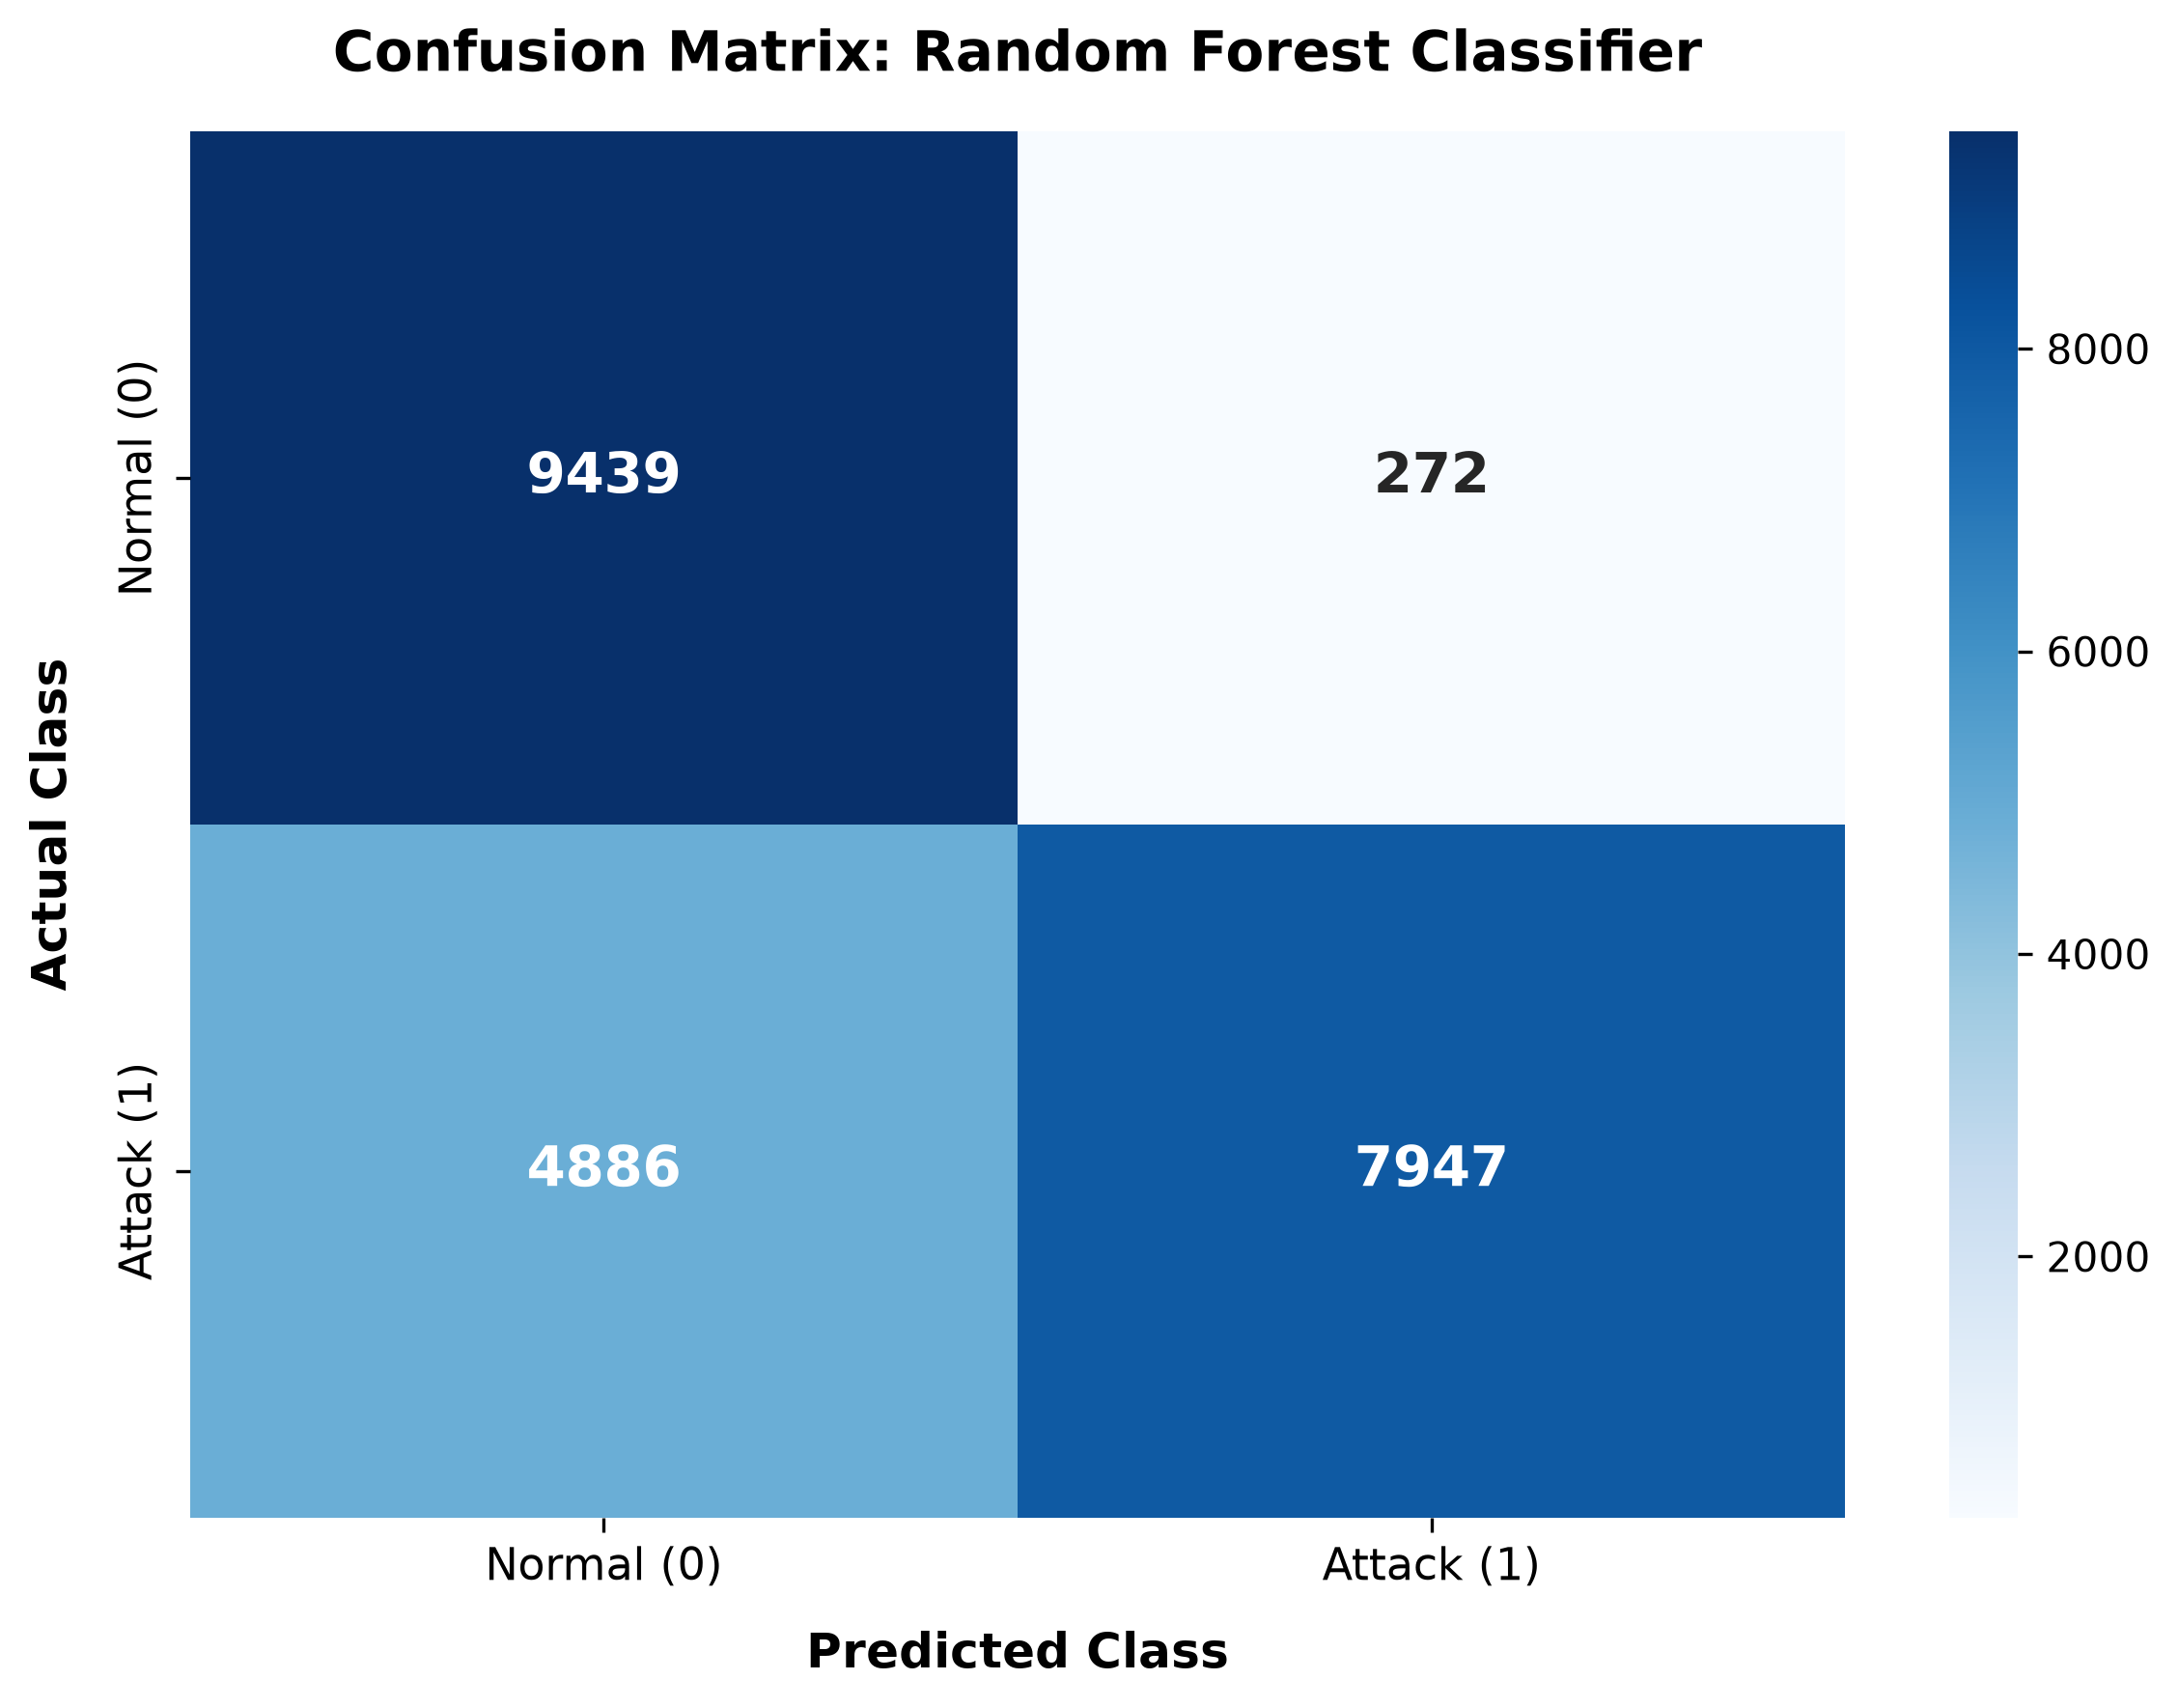

Confusion matrix heatmap saved to c:\Users\Mathuravan\Documents\IIT\Final year\FYP\FYP Project\CyberXAI\testing_outputs\confusion_matrix.png


In [6]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6), dpi=300)
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    cbar=True,
    xticklabels=["Normal (0)", "Attack (1)"],
    yticklabels=["Normal (0)", "Attack (1)"],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title("Confusion Matrix: Random Forest Classifier", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted Class", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Actual Class", fontsize=12, fontweight="bold", labelpad=10)
plt.tick_params(axis='both', which='major', labelsize=11)
plt.tight_layout()

cm_path = OUTPUT_DIR / "confusion_matrix.png"
plt.savefig(cm_path, bbox_inches="tight")
plt.show()
print(f"Confusion matrix heatmap saved to {cm_path}")


### Generate Classification Report


In [ ]:
report_dict = classification_report(y_test, y_pred, target_names=["Normal (0)", "Attack (1)"], output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print("Classification Report DataFrame:")
report_df


Classification Report DataFrame:


,precision,recall,f1-score,support
Normal (0),0.658918,0.971991,0.785405,9711.000000
Attack (1),0.966906,0.619263,0.754988,12833.000000
accuracy,0.771203,0.771203,0.771203,0.771203
macro avg,0.812912,0.795627,0.770196,22544.000000
weighted avg,0.834238,0.771203,0.768090,22544.000000
